<a href="https://colab.research.google.com/github/Andrew-lee0615/Quant-Strategies/blob/main/Strategy_02_BITCOIN_Crossover_ver2_0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_24079/1373160232.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period='10y', interval='1d')['Close'].squeeze().to_frame(name='Close')
[*********************100%***********************]  1 of 1 completed


--- BTC-USD Dynamic Risk-Off Report ---
Total Return: 13208.48%
CAGR: 63.08%
Max Drawdown (MDD): -38.76%
Final Value: $13,308,481.53


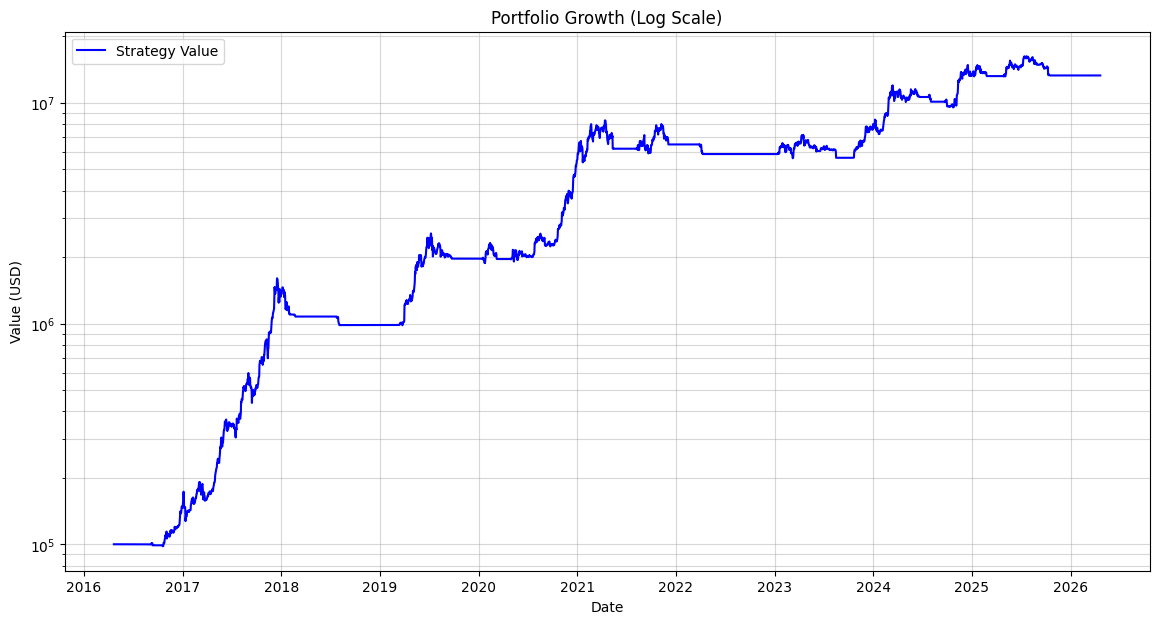

In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# 1. Data Retrieval
ticker = 'BTC-USD'
df = yf.download(ticker, period='10y', interval='1d')['Close'].squeeze().to_frame(name='Close')

# 2. Indicators
df['MA10'] = df['Close'].rolling(window=10).mean()
df['MA20'] = df['Close'].rolling(window=20).mean()
df['MA60'] = df['Close'].rolling(window=60).mean()
df['MA120'] = df['Close'].rolling(window=120).mean()

# 3. Signals
df['Above_MA120'] = df['Close'] > df['MA120']
df['MA120_5d_streak'] = df['Above_MA120'].rolling(window=5).sum() == 5
df['Is_Rising'] = df['Close'] > df['Close'].shift(1)

# 4. Initialization
initial_cash = 100000
cash = initial_cash
shares = 0
portfolio_values = []

# 5. Simulation
for i in range(len(df)):
    if i < 1:
        portfolio_values.append(initial_cash)
        continue

    price = df['Close'].iloc[i]
    ma10, ma20, ma60, ma120 = df['MA10'].iloc[i], df['MA20'].iloc[i], df['MA60'].iloc[i], df['MA120'].iloc[i]
    streak_5d = df['MA120_5d_streak'].iloc[i]
    is_rising = df['Is_Rising'].iloc[i]

    if pd.isna(ma120):
        portfolio_values.append(initial_cash)
        continue

    disparity = price / ma120
    is_extreme_overbought = disparity > 2.0
    is_caution_zone = disparity > 1.6

    # A. New Entry
    if (price >= ma120 * 1.05 or streak_5d) and cash > 0:
        buy_amt = cash * 0.25
        shares += buy_amt / price
        cash -= buy_amt

    # B. Dip Buying
    elif price > ma120 and not is_extreme_overbought and is_rising:
        buy_pct = 0
        if price <= ma60: buy_pct = 0.14
        elif price <= ma20: buy_pct = 0.07
        if is_caution_zone: buy_pct *= 0.5

        if buy_pct > 0 and cash > 0:
            buy_amt = cash * buy_pct
            shares += buy_amt / price
            cash -= buy_amt

    # C. Take Profit
    if shares > 0:
        if price >= ma10 * 1.15:
            sell_shares = shares * 0.30
            cash += sell_shares * price
            shares -= sell_shares
        elif price >= ma10 * 1.08:
            sell_shares = shares * 0.15
            cash += sell_shares * price
            shares -= sell_shares

    # D. Risk Management
    if shares > 0:
        if ma10 < ma20 and price > ma120:
            exit_pct = 0.40 if disparity > 1.6 else 0.20
            sell_shares = shares * exit_pct
            cash += sell_shares * price
            shares -= sell_shares
        elif price < ma120:
            if price < ma120 * 0.95:
                sell_shares = shares
            else:
                sell_shares = shares * 0.50
            cash += sell_shares * price
            shares -= sell_shares

    portfolio_values.append((shares * price) + cash)

# 6. Metrics
df['Portfolio_Value'] = portfolio_values
df['Peak'] = df['Portfolio_Value'].cummax()
df['Drawdown'] = (df['Portfolio_Value'] - df['Peak']) / df['Peak']

final_mdd = df['Drawdown'].min() * 100
final_val = df['Portfolio_Value'].iloc[-1]
total_return = ((final_val - initial_cash) / initial_cash) * 100
cagr = (((final_val / initial_cash) ** (1/10)) - 1) * 100

# 7. Results
print(f"--- BTC-USD Dynamic Risk-Off Report ---")
print(f"Total Return: {total_return:.2f}%")
print(f"CAGR: {cagr:.2f}%")
print(f"Max Drawdown (MDD): {final_mdd:.2f}%")
print(f"Final Value: ${final_val:,.2f}")

# 8. Visualization
plt.figure(figsize=(14, 7))
plt.plot(df.index, df['Portfolio_Value'], label='Strategy Value', color='blue')
plt.yscale('log')
plt.title('Portfolio Growth (Log Scale)')
plt.xlabel('Date')
plt.ylabel('Value (USD)')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()

In [ ]:
#단계	조건 / (Conditions)	행동 및 비중 (Action)
#신규 진입 /	MA120 돌파 (5일 유지 or +5% 돌파)	현금의 25%
#안전 매수 /	이격도 ≤ 1.6 구간 내 MA20 / MA60 터치	7% / 14% (양봉 확인)
#조심 매수 /	1.6 < 이격도 ≤ 2.0 구간 내 MA20 / MA60 터치	3.5% / 7% (비중 50% 축소)
#가변 선제 / 타격	MA10 < MA20 (단기 추세 이탈)	이격도 < 1.6: 20% / ≥ 1.6: 40%
#최종 탈출 /	주가 < MA120 (장기 추세 붕괴)	50% 매도 → 95% 지점 전량 매도